# Worksheet 7 -- Neural Networks-II

## Task 1&2

## Everything here is directly copied from the Neural Networks I task. The new code begins in Task 3!

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf

In [166]:
spectra = np.load("spectrums.npy")
print("Spectra array shape:", spectra.shape)

Spectra array shape: (41423, 52, 4)


In [167]:
wave_grid = spectra[:, :, 0]
spectrum = spectra[:, :, 1]
uncertainty = spectra[:, :, 2]
bin_width = spectra[:, :, 3]

In [168]:
# Is the same for each spectrum.
wg = wave_grid[0]
len(spectrum)

41423

In [169]:
print(f"Transit depth range: {spectrum.min():.1f} to {spectrum.max():.1f} ppm")
print(f"Mean uncertainty: {uncertainty.mean()} ppm")

Transit depth range: 0.0 to 0.1 ppm
Mean uncertainty: 7.327406919564325e-05 ppm


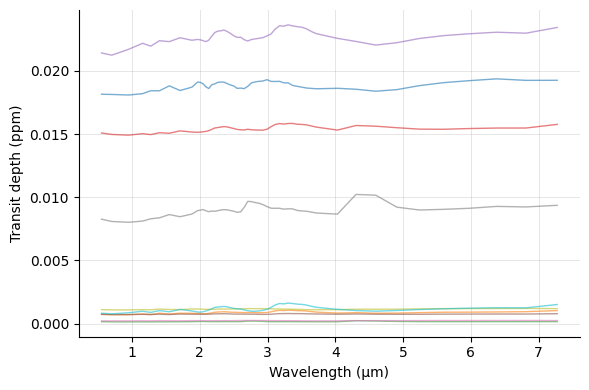

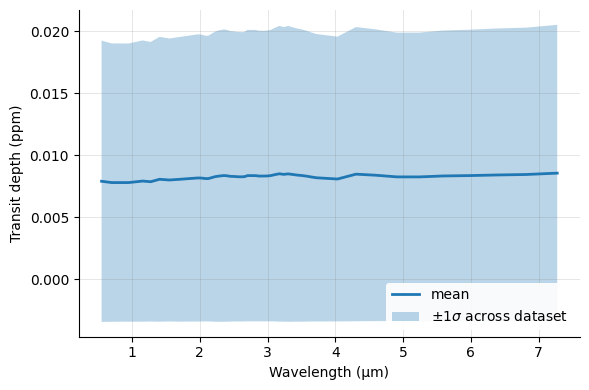

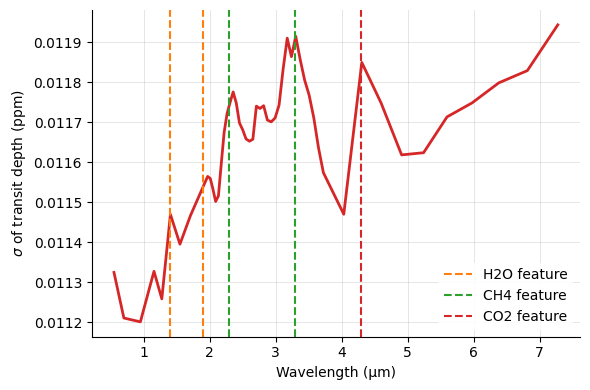

In [170]:
# Randomly chosen spectra
spec_idx = [100, 567, 10777, 23456, 37076, 40235, 19283, 856, 7451, 8254]
lines_info = {
    "H2O": {"wavelengths": [1.4, 1.9], "color": "C1"},
    "CH4": {"wavelengths": [2.3, 3.3], "color": "C2"},
    "CO2": {"wavelengths": [4.3], "color": "C3"}
}

mean_spec = spectrum.mean(axis=0)
std_spec = spectrum.std(axis=0)

# Figure 1 — 10 random example spectra
fig, ax = plt.subplots(figsize=(6, 4))
for i in spec_idx:
    ax.plot(wg, spectrum[i], alpha=0.6, lw=1)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Transit depth (ppm)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="gray", alpha=0.2, lw=0.7)
fig.tight_layout()
plt.show()

# Figure 2 — Population mean ± 1σ
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(wg, mean_spec, color="C0", lw=2, label="mean")
ax.fill_between(wg, mean_spec - std_spec, mean_spec + std_spec, alpha=0.3, label=r"$\pm1\sigma$ across dataset")
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Transit depth (ppm)")
ax.legend(framealpha=0.9, edgecolor="none")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="gray", alpha=0.2, lw=0.7)
fig.tight_layout()
plt.show()

# Figure 3 — Variability vs wavelength
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(wg, std_spec, color="C3", lw=2)
for compound, info in lines_info.items():
    for j, wavelength in enumerate(info["wavelengths"]):
        label = f"{compound} feature" if j == 0 else None
        ax.axvline(wavelength, color=info["color"], ls="--", label=label)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel(r"$\sigma$ of transit depth (ppm)")
ax.legend(framealpha=0.9, edgecolor="none")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="gray", alpha=0.2, lw=0.7)
fig.tight_layout()
plt.show()

## Task 3

### Preprocessing

In [171]:
labels = pd.read_csv("FM_Parameter_Table.csv")
aux_df = pd.read_csv("AuxillaryTable.csv")
display(labels)

,Unnamed: 0,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...,...
41418,41418,train41419,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,41419,train41420,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,41420,train41421,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,41421,train41422,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


In [172]:
targets = ["planet_radius", "planet_temp", "log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]
Y_all = labels[targets].values

In [173]:
aux = pd.DataFrame({
    "log_star_distance": np.log10(aux_df["star_distance"]),
    "log_star_mass":     np.log10(aux_df["star_mass_kg"]),
    "log_star_radius":   np.log10(aux_df["star_radius_m"]),
    "star_temperature":  aux_df["star_temperature"],
    "log_planet_mass":   np.log10(aux_df["planet_mass_kg"]),
    "log_orbital_period":np.log10(aux_df["planet_orbital_period"]),
    "log_planet_dist":   np.log10(aux_df["planet_distance"]),
    "log_surface_grav":  np.log10(aux_df["planet_surface_gravity"]),
}).values

**FIX 1 — keep the spectrum as a sequence.**

Conv1D needs input shape `(batch, steps, channels)`. We stack `spectrum` and `uncertainty` along a new channel axis so each spectrum is a length-52 sequence with 2 channels. `wave_grid` and `bin_width` are identical for every spectrum in this dataset, so they carry no information that varies between examples — dropping them keeps the model lean. The aux features stay as a separate 2D matrix; they are *not* concatenated to the spectrum because they are not wavelength-bin quantities.

In [174]:
# Spectrum-only input: (N, 52, 2) -- per-bin channels [spectrum, uncertainty]
X_spec = np.stack([spectrum, uncertainty], axis=-1)

# Aux input stays separate; it will be fed through its own Dense branch
X_aux = aux

print(f"X_spec shape: {X_spec.shape}")
print(f"X_aux  shape: {X_aux.shape}")
print(f"Y_all  shape: {Y_all.shape}")

X_spec shape: (41423, 52, 2)
X_aux  shape: (41423, 8)
Y_all  shape: (41423, 7)


In [175]:
# Use identical splits (same random_state) so the two models see the same train/val/test rows.
Xs_left, Xs_test, Y_left, Y_test = train_test_split(X_spec, Y_all, test_size=0.1, random_state=42)
Xs_train, Xs_val, Y_train, Y_val = train_test_split(Xs_left, Y_left, test_size=0.111, random_state=42)

# Aux gets the same split (same random_state -> same row ordering)
Xa_left, Xa_test, _, _ = train_test_split(X_aux, Y_all, test_size=0.1, random_state=42)
Xa_train, Xa_val, _, _ = train_test_split(Xa_left, Y_left, test_size=0.111, random_state=42)

In [176]:
print(f"Spectrum  -> Train: {Xs_train.shape}, Val: {Xs_val.shape}, Test: {Xs_test.shape}")
print(f"Aux       -> Train: {Xa_train.shape}, Val: {Xa_val.shape}, Test: {Xa_test.shape}")

Spectrum  -> Train: (33141, 52, 2), Val: (4139, 52, 2), Test: (4143, 52, 2)
Aux       -> Train: (33141, 8), Val: (4139, 8), Test: (4143, 8)


**FIX 2 — scale the spectrum per-channel, not per-position.**

`StandardScaler` from sklearn expects a 2D matrix, so it cannot directly handle the 3D spectrum tensor. We compute the per-channel mean and standard deviation across all training samples and all wavelength bins (`axis=(0, 1)`). This gives one (mean, std) pair per channel, which is the standard convention for CNNs and preserves the relative shape of each spectrum across wavelength. The aux table and the targets keep using `StandardScaler` exactly as before.

In [177]:
# Per-channel scaling for the 3D spectrum tensor.
ch_mean = Xs_train.mean(axis=(0, 1), keepdims=True)      # shape (1, 1, 2)
ch_std  = Xs_train.std(axis=(0, 1),  keepdims=True) + 1e-12
def scale_spec(x): return (x - ch_mean) / ch_std

Xs_train_s = scale_spec(Xs_train)
Xs_val_s   = scale_spec(Xs_val)
Xs_test_s  = scale_spec(Xs_test)

# Aux: ordinary StandardScaler (it's already 2D).
Xa_scaler = StandardScaler().fit(Xa_train)
Xa_train_s = Xa_scaler.transform(Xa_train)
Xa_val_s   = Xa_scaler.transform(Xa_val)
Xa_test_s  = Xa_scaler.transform(Xa_test)

# Targets: same as before.
Y_scaler = StandardScaler().fit(Y_train)
Y_train_s = Y_scaler.transform(Y_train)
Y_val_s   = Y_scaler.transform(Y_val)
Y_test_s  = Y_scaler.transform(Y_test)

### Building the Model

**FIX 3 — two architectures.**

- `build_cnn_spec` is the spectrum-only CNN. The only change from your original is the input shape, which is now `(n_bins, n_channels)` instead of `(n_inputs,)`. Everything downstream is identical.

- `build_cnn_with_aux` is a **two-branch** model. The spectrum branch is the same CNN; the aux branch is a small MLP. After both branches have produced a flat feature vector, they are concatenated and passed to the final Dense head. This is how CNNs are routinely combined with tabular features.

In [178]:
def build_cnn_spec(n_bins, n_channels, n_outputs):
    inp = tf.keras.Input(shape=(n_bins, n_channels))

    x = tf.keras.layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(inp)
    x = tf.keras.layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)                # 52 -> 26

    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)                # 26 -> 13

    x = tf.keras.layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)                 # 13 -> single vector

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_outputs, activation='linear')(x)  # regression -> linear

    return tf.keras.Model(inp, out)


def build_cnn_with_aux(n_bins, n_channels, n_aux, n_outputs):
    # --- Spectrum branch (identical to build_cnn_spec, minus the final head) ---
    spec_in = tf.keras.Input(shape=(n_bins, n_channels), name='spectrum')
    s = tf.keras.layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(spec_in)
    s = tf.keras.layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(s)
    s = tf.keras.layers.MaxPooling1D(pool_size=2)(s)

    s = tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(s)
    s = tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(s)
    s = tf.keras.layers.MaxPooling1D(pool_size=2)(s)

    s = tf.keras.layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(s)
    s = tf.keras.layers.GlobalAveragePooling1D()(s)

    # --- Aux branch: small MLP that lifts the 8 aux features into a 32-d vector ---
    aux_in = tf.keras.Input(shape=(n_aux,), name='aux')
    a = tf.keras.layers.Dense(32, activation='relu')(aux_in)
    a = tf.keras.layers.Dense(32, activation='relu')(a)

    # --- Merge and shared head ---
    x = tf.keras.layers.Concatenate()([s, a])
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_outputs, activation='linear')(x)

    return tf.keras.Model([spec_in, aux_in], out)


tf.keras.utils.set_random_seed(42)
model_spec = build_cnn_spec(
    n_bins=Xs_train_s.shape[1],
    n_channels=Xs_train_s.shape[2],
    n_outputs=Y_train_s.shape[1],
)
model_spec.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="mse", metrics=["mae"])

tf.keras.utils.set_random_seed(42)
model_full = build_cnn_with_aux(
    n_bins=Xs_train_s.shape[1],
    n_channels=Xs_train_s.shape[2],
    n_aux=Xa_train_s.shape[1],
    n_outputs=Y_train_s.shape[1],
)
model_full.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="mse", metrics=["mae"])

model_spec.summary()
model_full.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 52, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_66 (Conv1D)              │ (None, 52, 32)         │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_67 (Conv1D)              │ (None, 52, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_68 (Conv1D)              │ (None, 26, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_69 (Conv1D)              │ (None, 26, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_70 (Conv1D)              │ (None, 13, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_13     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,007 (250.03 KB)

 Trainable params: 64,007 (250.03 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrum            │ (None, 52, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, 52, 32)    │        224 │ spectrum[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, 52, 32)    │      3,104 │ conv1d_71[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_28    │ (None, 26, 32)    │          0 │ conv1d_72[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_73 (Conv1D)  │ (None, 26, 64)    │      6,208 │ max_pooling1d_28… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_74 (Conv1D)  │ (None, 26, 64)    │     12,352 │ conv1d_73[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_29    │ (None, 13, 64)    │          0 │ conv1d_74[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux (InputLayer)    │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, 13, 128)   │     24,704 │ max_pooling1d_29… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 32)        │        288 │ aux[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_75[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 32)        │      1,056 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 128)       │          0 │ dense_29[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 7)         │        903 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,447 (271.28 KB)

 Trainable params: 69,447 (271.28 KB)

 Non-trainable params: 0 (0.00 B)

In [179]:
# Factory so each model gets its own callback instances.
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ]

**FIX 4 — feed the aux model with a list of inputs.**

A multi-input Keras model is fitted by passing a list (or dict) of arrays in the position where you would normally pass a single one. The order must match the `Input` order in `build_cnn_with_aux`: spectrum first, then aux.

In [180]:
# Train both models with identical hyperparameters.
print("Training spectrum-only model...")
history_spec = model_spec.fit(
    Xs_train_s, Y_train_s,
    validation_data=(Xs_val_s, Y_val_s),
    epochs=300, batch_size=128, callbacks=make_callbacks(), verbose=2,
)

print("\nTraining spectrum + aux model...")
history_full = model_full.fit(
    [Xs_train_s, Xa_train_s], Y_train_s,
    validation_data=([Xs_val_s, Xa_val_s], Y_val_s),
    epochs=300, batch_size=128, callbacks=make_callbacks(), verbose=2,
)

Training spectrum-only model...
Epoch 1/300
259/259 - 2s - 7ms/step - loss: 0.8777 - mae: 0.7717 - val_loss: 0.8558 - val_mae: 0.7591 - learning_rate: 0.0010
Epoch 2/300
259/259 - 1s - 3ms/step - loss: 0.8557 - mae: 0.7578 - val_loss: 0.8375 - val_mae: 0.7469 - learning_rate: 0.0010
Epoch 3/300
259/259 - 1s - 3ms/step - loss: 0.8416 - mae: 0.7492 - val_loss: 0.8337 - val_mae: 0.7391 - learning_rate: 0.0010
Epoch 4/300
259/259 - 1s - 3ms/step - loss: 0.8270 - mae: 0.7401 - val_loss: 0.8074 - val_mae: 0.7260 - learning_rate: 0.0010
Epoch 5/300
259/259 - 1s - 3ms/step - loss: 0.8131 - mae: 0.7319 - val_loss: 0.8017 - val_mae: 0.7283 - learning_rate: 0.0010
Epoch 6/300
259/259 - 1s - 3ms/step - loss: 0.7807 - mae: 0.7144 - val_loss: 0.7475 - val_mae: 0.6910 - learning_rate: 0.0010
Epoch 7/300
259/259 - 1s - 3ms/step - loss: 0.7297 - mae: 0.6840 - val_loss: 0.7129 - val_mae: 0.6656 - learning_rate: 0.0010
Epoch 8/300
259/259 - 1s - 3ms/step - loss: 0.6956 - mae: 0.6638 - val_loss: 0.6654 - 

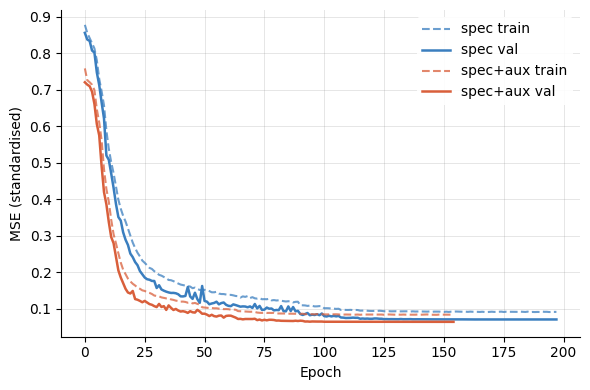

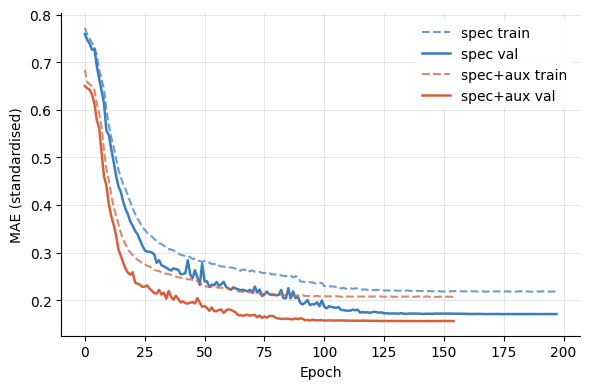

In [181]:
SPEC_COLOR = "#3A7EBF"
FULL_COLOR = "#D95F3B"

# Figure 1 — Loss curves
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_spec.history["loss"],     label="spec train",     color=SPEC_COLOR, ls="--", lw=1.5, alpha=0.75)
ax.plot(history_spec.history["val_loss"], label="spec val",       color=SPEC_COLOR, lw=1.8)
ax.plot(history_full.history["loss"],     label="spec+aux train", color=FULL_COLOR, ls="--", lw=1.5, alpha=0.75)
ax.plot(history_full.history["val_loss"], label="spec+aux val",   color=FULL_COLOR, lw=1.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (standardised)")
ax.legend(framealpha=0.9, edgecolor="none")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="gray", alpha=0.2, lw=0.7)
fig.tight_layout()
plt.show()

# Figure 2 — MAE curves
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_spec.history["mae"],     label="spec train",     color=SPEC_COLOR, ls="--", lw=1.5, alpha=0.75)
ax.plot(history_spec.history["val_mae"], label="spec val",       color=SPEC_COLOR, lw=1.8)
ax.plot(history_full.history["mae"],     label="spec+aux train", color=FULL_COLOR, ls="--", lw=1.5, alpha=0.75)
ax.plot(history_full.history["val_mae"], label="spec+aux val",   color=FULL_COLOR, lw=1.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (standardised)")
ax.legend(framealpha=0.9, edgecolor="none")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="gray", alpha=0.2, lw=0.7)
fig.tight_layout()
plt.show()

### Predict labels

In [182]:
# Predict on the test set with both models and invert the target scaling back to physical units.
y_pred_spec = Y_scaler.inverse_transform(model_spec.predict(Xs_test_s))
y_pred_full = Y_scaler.inverse_transform(model_full.predict([Xs_test_s, Xa_test_s]))

# Per-target MAE and R^2 for both models, plus the improvement gained from the auxiliary features.
print(f"{'Label':<15} {'MAE_spec':>10} {'MAE_full':>10} {'ΔMAE':>10}  "
      f"{'R²_spec':>10} {'R²_full':>10} {'ΔR²':>10}")
for i, name in enumerate(targets):
    mae_s = mean_absolute_error(Y_test[:, i], y_pred_spec[:, i])
    mae_f = mean_absolute_error(Y_test[:, i], y_pred_full[:, i])
    r2_s = r2_score(Y_test[:, i], y_pred_spec[:, i])
    r2_f = r2_score(Y_test[:, i], y_pred_full[:, i])
    print(f"{name:<15} {mae_s:>10.4f} {mae_f:>10.4f} {mae_f - mae_s:>+10.4f}  "
          f"{r2_s:>10.4f} {r2_f:>10.4f} {r2_f - r2_s:>+10.4f}")

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Label             MAE_spec   MAE_full       ΔMAE     R²_spec    R²_full        ΔR²
planet_radius       0.0716     0.0234    -0.0481      0.9431     0.9952    +0.0521
planet_temp        46.9972    38.0039    -8.9934      0.9609     0.9851    +0.0242
log_H2O             0.3257     0.3402    +0.0144      0.9192     0.9139    -0.0053
log_CO2             0.1843     0.1788    -0.0054      0.9664     0.9683    +0.0019
log_CO              0.1983     0.2057    +0.0073      0.8646     0.8762    +0.0116
log_CH4             0.2188     0.2258    +0.0070      0.9634     0.9608    -0.0026
log_NH3             0.3348     0.3478    +0.0129      0.8830     0.8770    -0.0060


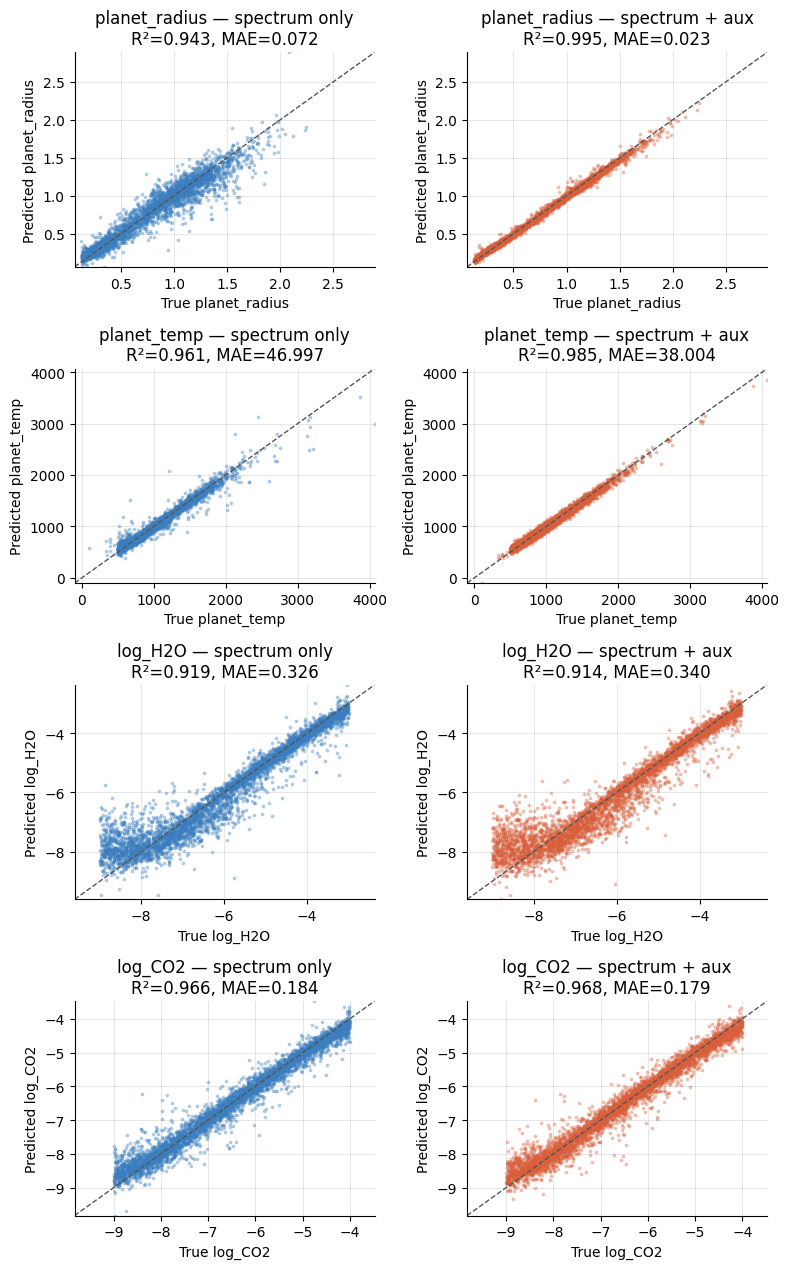

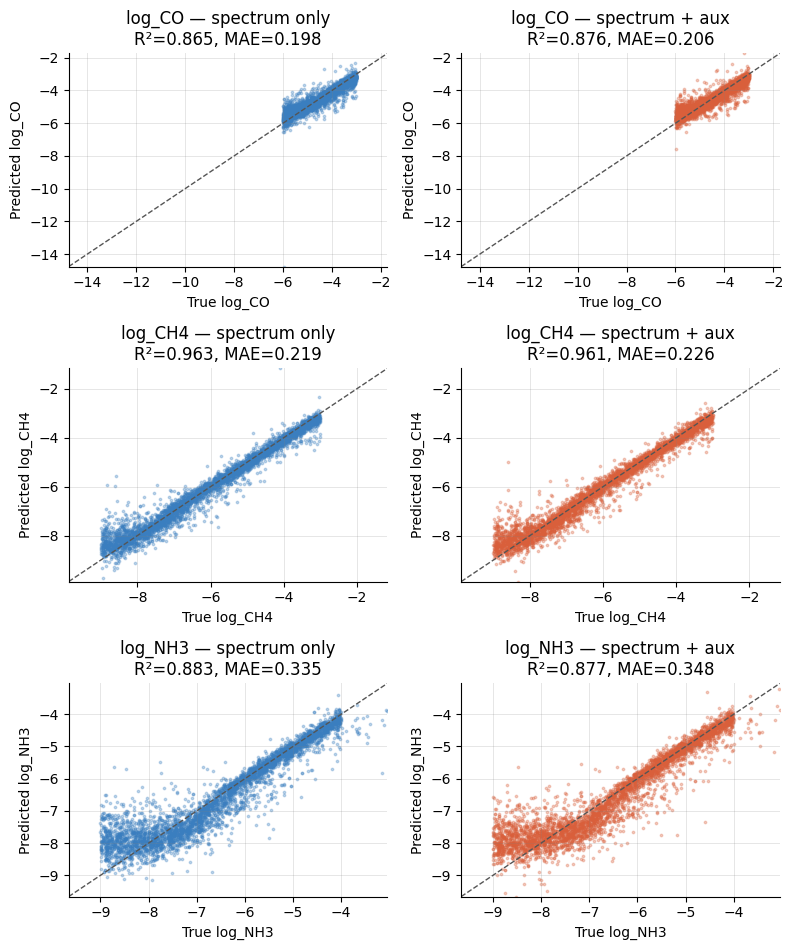

In [183]:
SPEC_COLOR = "#3A7EBF"
FULL_COLOR = "#D95F3B"

# Split the 7 targets into two groups so each figure is short enough to fit on a page.
target_groups = [targets[:4], targets[4:]]  # part 1: through log_CO2 · part 2: log_CO onward

for group in target_groups:
    n_grp = len(group)
    fig, axes = plt.subplots(n_grp, 2, figsize=(8, 3.2 * n_grp))

    for k, name in enumerate(group):
        i = targets.index(name)
        lims = [min(Y_test[:, i].min(), y_pred_spec[:, i].min(), y_pred_full[:, i].min()),
                max(Y_test[:, i].max(), y_pred_spec[:, i].max(), y_pred_full[:, i].max())]

        for j, (y_pred, tag, color) in enumerate(
            [(y_pred_spec, "spectrum only", SPEC_COLOR), (y_pred_full, "spectrum + aux", FULL_COLOR)]
        ):
            ax = axes[k, j]
            ax.scatter(Y_test[:, i], y_pred[:, i], s=3, alpha=0.3, color=color)
            ax.plot(lims, lims, color="#555555", lw=1, ls="--")
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_xlabel(f"True {name}"); ax.set_ylabel(f"Predicted {name}")
            r2_i = r2_score(Y_test[:, i], y_pred[:, i])
            mae_i = mean_absolute_error(Y_test[:, i], y_pred[:, i])
            ax.set_title(f"{name} — {tag}\nR²={r2_i:.3f}, MAE={mae_i:.3f}")
            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(True, color="gray", alpha=0.2, lw=0.7)

    plt.tight_layout()
    plt.show()